# SWIGGY  SALES ANALYSIS PROJECT

## IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

## IMPORT DATA INTO PYTHON EXCEL FORMAT 

In [ ]:
 df = pd.read_excel('swiggy_data.xlsx')

In [ ]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [ ]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### META DATA

In [ ]:
print("No of Rows:",df.shape[0])

No of Rows: 197430


In [ ]:
print("No of Columns:",df.shape[1])

No of Columns: 10


In [ ]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

## Chek the Data types 

In [ ]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [ ]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


# Swigy Project KPI'S

### Total_Sales

In [ ]:
Total_Sales = df["Price (INR)"].sum()
print("Total Sales (INR):", round(Total_Sales,2))

Total Sales (INR): 53012505.77


## Average_Rating

In [ ]:
Average_Rating = df["Rating"].mean()
print("Average Rating", round(Average_Rating,1))

Average Rating 4.3


## Average_Orders Values

In [ ]:
Avg_order = df["Price (INR)"].mean()
print("Avg Order", round(Avg_order,2))

Avg Order 268.51


## Ratings Counts

In [ ]:
Rating_count = df["Price (INR)"].sum()
print("Rating counts", round(Rating_count,2))

Rating counts 53012505.77


## Total Orders

In [ ]:
total_Orders = len(df)
print("Total Orders Number:", (total_Orders))

Total Orders Number: 197430


# Let's Move Next Step For Design Chart 

## Monthly Sales Trends 

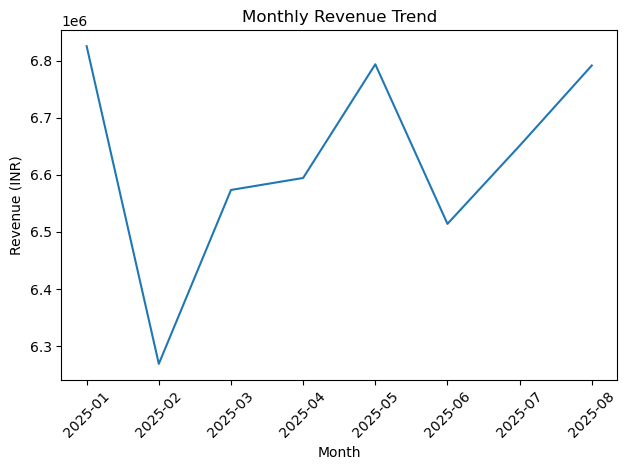

In [ ]:
# 1. Convert to datetime object
df["Order Date"] = pd.to_datetime(df["Order Date"])

# 2. Corrected line: Added the dot before dt
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

# 3. Aggregate revenue by year-month
monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

# 4. Plot the results
plt.figure()
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

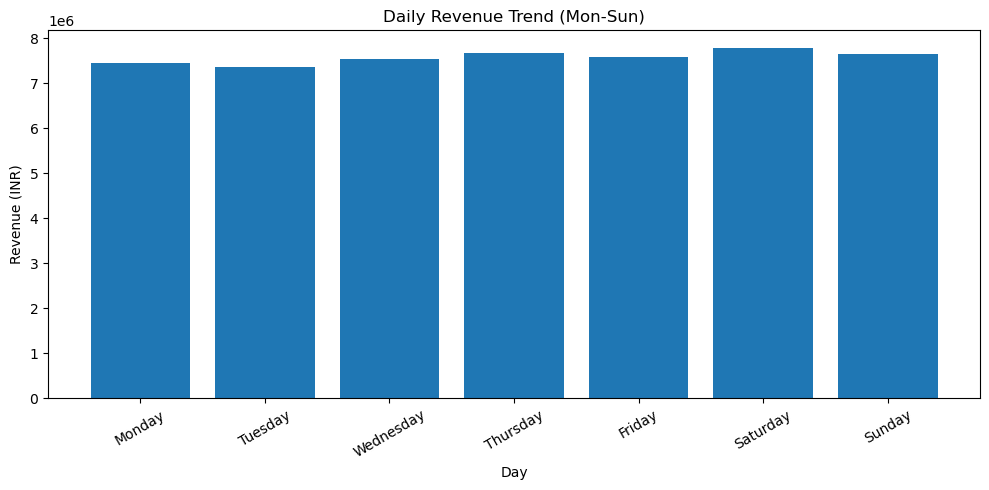

In [ ]:

# 1. Extract day name from the order date
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

# 2. Group, sum, and force chronological order
cats = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_revenue = df.groupby("DayName")["Price (INR)"].sum().reindex(cats)

# 3. Plot the bar chart
plt.figure(figsize=(10, 5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)
plt.tight_layout() # Recommended to prevent x-axis labels from getting cut off
plt.show()

# Total Sales by Food Category (Veg and Non-Veg)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "biryani", "kabab", "kebab",
    "non-veg", "non veg"
]

# Join keywords with word boundaries: \b(keyword1|keyword2)\b
regex_pattern = r"\b(" + "|".join(non_veg_keywords) + r")\b"

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains(regex_pattern, na=False, regex=True),
    "Non-Veg",
    "Veg"
)

In [ ]:

# 1. Aggregate revenue (kept identical to your logic)
food_revenue = (
    df.groupby("Food Category")["Price (INR)"]
    .sum()
    .reset_index()
)

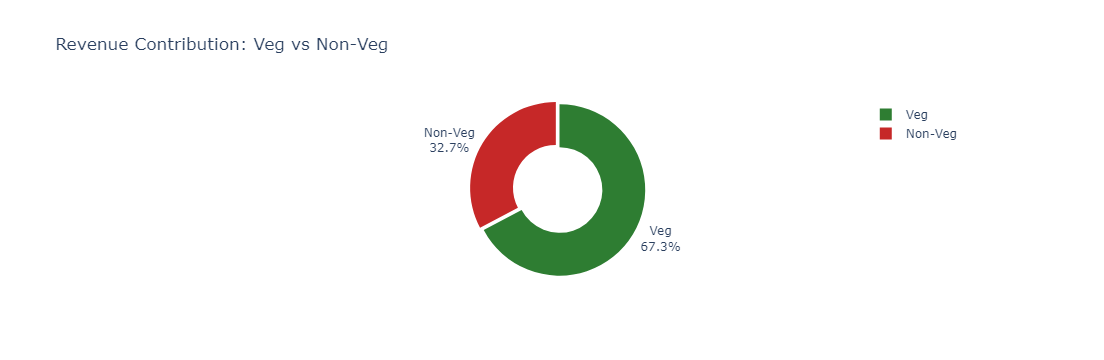

In [ ]:
# 2. Plot custom donut chart
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
    # Custom color mapping matching standard food industry indicators
    color="Food Category",
    color_discrete_map={"Veg": "#2e7d32", "Non-Veg": "#c62828"} 
)

# 3. Refine trace text and pull presentation
fig.update_traces(
    textinfo="label+percent",
    textposition="outside",  # Prevents overlapping text inside thin slices
    pull=[0.05 if cat == "Non-Veg" else 0 for cat in food_revenue["Food Category"]],
    hovertemplate="<b>%{label}</b><br>Revenue: ₹%{value:,.2f}<br>Share: %{percent}<extra></extra>"
)

# Total Sales by State 

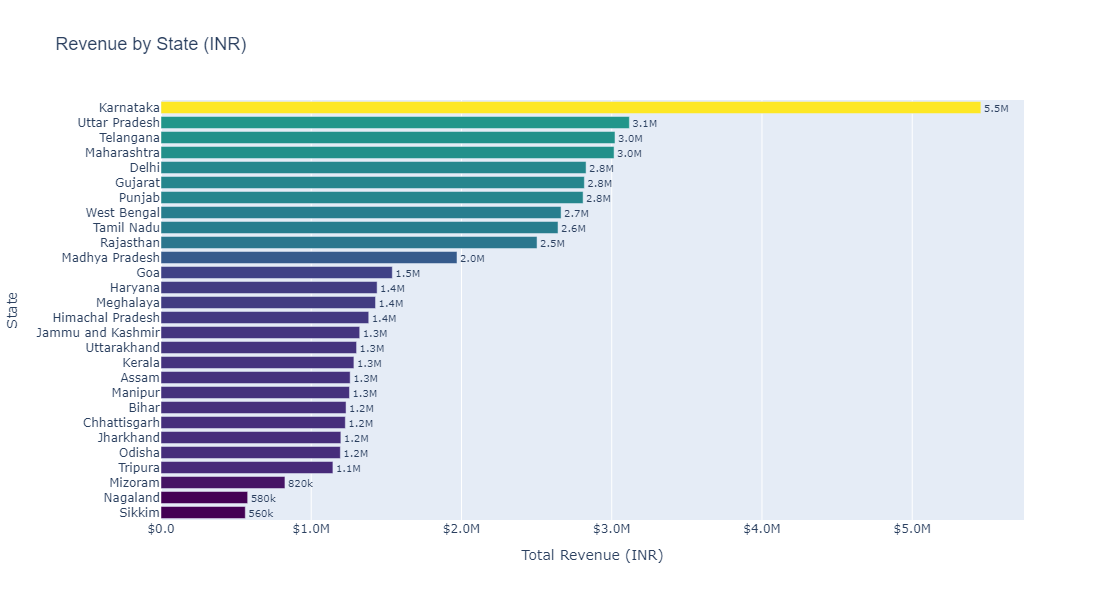

In [ ]:
# 1. Generate the bar chart with custom styling
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
    .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)",
    text_auto=".2s",  # Automatically adds clean abbreviated labels (e.g., 1.5M, 450k)
    color="Price (INR)",  # Applies a beautiful sequential color gradient based on value
    color_continuous_scale="Viridis"  # Professional multi-hue color scheme
)

# 2. Refine layout and formatting
fig.update_layout(
    height=600, 
    yaxis=dict(autorange="reversed", title="State"),
    xaxis=dict(title="Total Revenue (INR)", tickformat="$,.2s"),  # Clean formatting for x-axis
    title_font=dict(size=18, family="Arial"),
    coloraxis_showscale=False  # Hides the color legend bar to keep the chart clean
)

# 3. Adjust text position for readability
fig.update_traces(textposition="outside")

fig.show()

# Quaterly Performance Summery

In [ ]:
# 1. Parse dates and create clean Quarter periods
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)

# 2. Compute aggregate summary metrics (kept identical to your logic)
quarterly_summary = (
    df.groupby("Quarter", as_index=False)
    .agg(
        Total_Sales=("Price (INR)", "sum"),
        Avg_Rating=("Rating", "mean"),
        Total_Orders=("Order_Date", "count")
    )
    .sort_values("Quarter")
)

# 3. Apply professional presentation styling
styled_summary = quarterly_summary.style.format({
    "Total_Sales": "₹{:,.2f}",      # Formats sales as clean Indian Rupee values
    "Avg_Rating": "{:.2f} ★",       # Rounds ratings to 2 decimal places with a star icon
    "Total_Orders": "{:,}"          # Adds thousand separators to order counts
}).background_gradient(
    subset=["Total_Sales"], 
    cmap="Blues"                    # Visually highlights the highest revenue quarters
).hide(axis="index")               # Hides the ugly default index column

# Display the polished table in your Jupyter Notebook
styled_summary

Quarter,Total_Sales,Avg_Rating,Total_Orders
2025Q1,"₹19,667,821.77",4.34 ★,"73,096"
2025Q2,"₹19,902,256.59",4.34 ★,"74,163"
2025Q3,"₹13,442,427.41",4.34 ★,"50,171"


# Top 5 Coties Sales by 

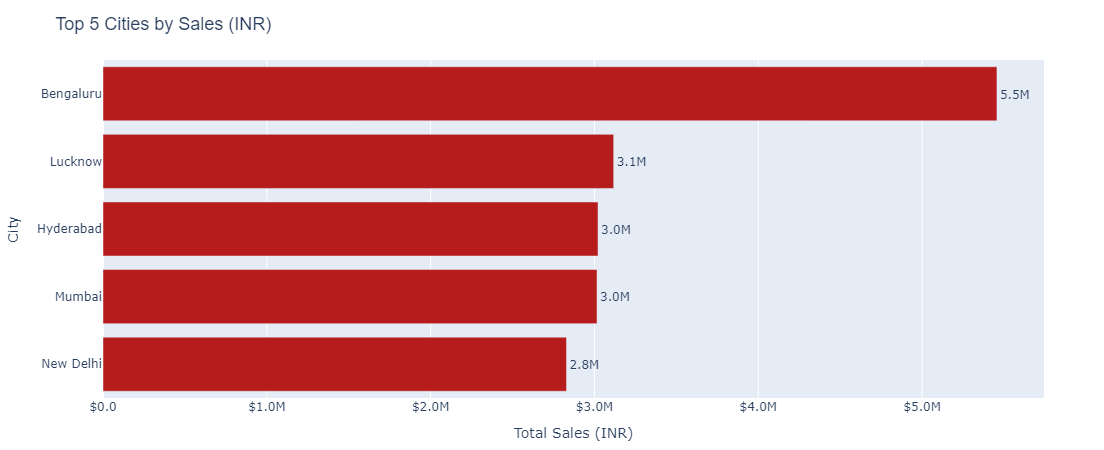

In [ ]:
# 1. Fetch top 5 data (kept identical to your aggregation logic)
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

# 2. Build the polished chart
fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    text_auto=".2s",  # Adds abbreviated clean labels (e.g., 2.5M, 850k) onto the bars
    # Swapping stark solid red for a premium, intentional brand shade
    color_discrete_sequence=["#b71c1c"] 
)

# 3. Clean up presentation layout
fig.update_layout(
    height=450,
    xaxis=dict(title="Total Sales (INR)", tickformat="$,.2s"),  # Clean currency abbreviation
    yaxis=dict(title="City"),
    title_font=dict(size=18, family="Arial"),
    margin=dict(t=60, b=40, l=40, r=60)
)

# 4. Push text labels outside for clear visibility
fig.update_traces(textposition="outside")

fig.show()